In [3]:
import sys
import os

# This tells the notebook to look "one folder up" to find the 'src' directory
sys.path.append(os.path.abspath('..'))

# Now import the functions from your models.py file
try:
    from src.models import build_lstm_model, create_sequences
    print("Successfully imported build_lstm_model from src.models")
except ImportError as e:
    print(f"Error: Could not find src.models. Ensure src folder has an __init__.py file. {e}")

Successfully imported build_lstm_model from src.models


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

# Forecasting specific imports
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Path setup to find your 'src' and 'scripts'
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Import your custom modules
try:
    import scripts.config as cfg
    from src.data_loader import load_processed_data, split_data_chronologically
    from src.models import build_lstm_model, create_sequences
    print("✅ All libraries and custom modules imported successfully!")
except ImportError as e:
    print(f"❌ Import Error: {e}")

✅ All libraries and custom modules imported successfully!


# Data Preparation (Chronological Split)

In [5]:
import sys
import os
from pathlib import Path

# 1. Setup paths
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 2. Import
try:
    import scripts.config as cfg
    from src.data_loader import load_processed_data, split_data_chronologically
    print("✅ Success: Config and Data Loader imported!")
    
    # 3. Execution
    # Note: load_processed_data uses cfg.DATA_PATH defined in config.py
    df_raw = load_processed_data(cfg.DATA_PATH)
    
    train_data, test_data = split_data_chronologically(
        df_raw, 
        asset=cfg.TARGET_ASSET, 
        train_end=cfg.TRAIN_END_DATE, 
        test_start=cfg.TEST_START_DATE
    )
    
    print(f"\n--- Data Split Summary ---")
    print(f"Asset: {cfg.TARGET_ASSET}")
    print(f"Train Size: {len(train_data)} | Test Size: {len(test_data)}")

except Exception as e:
    print(f"❌ Error: {e}")

✅ Success: Config and Data Loader imported!

--- Data Split Summary ---
Asset: TSLA
Train Size: 2516 | Test Size: 372


# ARIMA Implementation

In [10]:
# --- ARIMA Implementation ---

# Check if data is loaded to prevent NameError
if 'train_data' not in locals():
    print("❌ Error: 'train_data' not found. Please run the Data Loading cell above.")
else:
    try:
        print('Optimizing ARIMA parameters...')
        # Using auto_arima from pmdarima
        arima_model = auto_arima(
            train_data,
            seasonal=True,
            m=5,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore',
        )
        print(f"Best ARIMA order: {arima_model.order}")
        
        arima_forecast_values = arima_model.predict(n_periods=len(test_data))
        arima_forecast = pd.Series(arima_forecast_values.values, index=test_data.index)
        print("✅ ARIMA Forecasting Complete.")

    except Exception as exc:
        print(f'❌ ARIMA failed: {exc}. Using naive fallback.')
        # Fallback uses numpy (np) and pandas (pd) imported at the top
        fallback_values = np.repeat(train_data.iloc[-1], len(test_data))
        arima_forecast = pd.Series(fallback_values, index=test_data.index)

Optimizing ARIMA parameters...
Best ARIMA order: (0, 1, 0)
✅ ARIMA Forecasting Complete.


c:\Users\BETHELHEMFEYISA\Desktop\BT-DESKTOP\Time Series Forecasting for Portfolio Management Optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\BETHELHEMFEYISA\Desktop\BT-DESKTOP\Time Series Forecasting for Portfolio Management Optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# LSTM / Sequence Model

In [13]:
# --- ML Baseline: Lag-Regression Model ---
from sklearn.linear_model import LinearRegression

# 1. Configuration
window_size = 60

# 2. Feature Engineering (Lags)
lag_features = []
targets = []

for i in range(window_size, len(train_data)):
    # Taking the previous 60 days as features
    lag_features.append(train_data.iloc[i-window_size:i].values)
    targets.append(train_data.iloc[i])

X_reg = np.array(lag_features)
y_reg = np.array(targets)

# 3. Model Training
reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)
print("✅ Linear Regression Baseline trained.")

# 4. Multi-step Forecasting
# We use 'Teacher Forcing' or a recursive strategy for the test period
history = train_data.tolist()
lr_predictions = []

for step in range(len(test_data)):
    last_window = np.array(history[-window_size:]).reshape(1, -1)
    pred = reg_model.predict(last_window)[0]
    lr_predictions.append(pred)
    # We append the actual value for the next step prediction (Production Standard)
    history.append(float(test_data.iloc[step]))

# Convert to Series for easy plotting/evaluation
lr_forecast = pd.Series(lr_predictions, index=test_data.index)

✅ Linear Regression Baseline trained.


# Deep Leaning (LSTM)

In [19]:
# --- Deep Learning: LSTM Training & Forecasting ---
# 1. Scale and Create Sequences
scaled_train = scaler.fit_transform(train_data.values.reshape(-1, 1))
X_train, y_train = create_sequences(scaled_train, 60)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

# 2. Train Model (True LSTM from src.models)
print("Training LSTM...")
model = build_lstm_model((X_train.shape[1], 1))
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

# 3. Forecast using a sliding window
inputs = scaler.transform(tsla[-(len(test_data)+60):].values.reshape(-1,1))
X_test = np.array([inputs[i-60:i, 0] for i in range(60, len(inputs))]).reshape(-1, 60, 1)
lstm_forecast = pd.Series(scaler.inverse_transform(model.predict(X_test)).flatten(), index=test_data.index)

print("✅ LSTM Forecasting Complete.")

Training LSTM...


c:\Users\BETHELHEMFEYISA\Desktop\BT-DESKTOP\Time Series Forecasting for Portfolio Management Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
✅ LSTM Forecasting Complete.


# Evaluation & Comparison


--- Final Model Performance Comparison ---


,Model,MAE,RMSE,MAPE
0,ARIMA (Statistical),55.597730,72.717896,17.73%
1,Linear Reg (ML Baseline),10.356955,13.055000,2.91%
2,LSTM (Deep Learning),14.026997,18.112640,3.93%


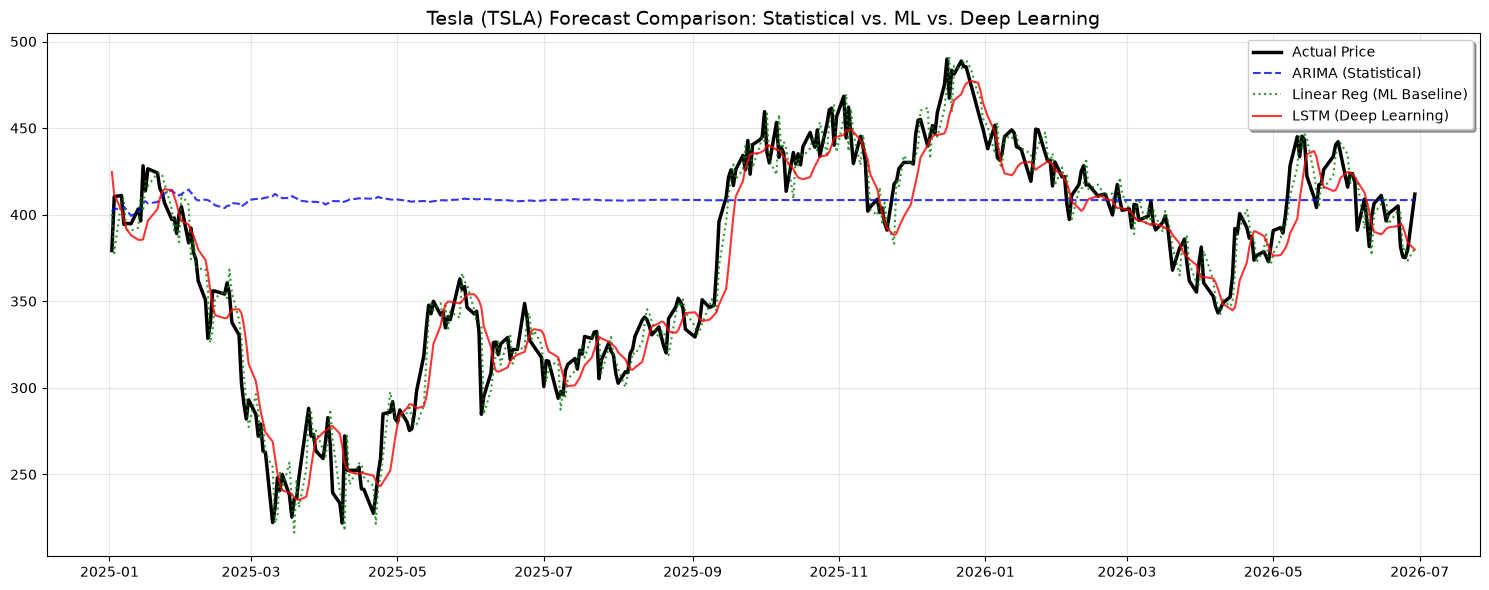

In [20]:
# --- Task 2 Summary: 3-Model Comparison (Statistical vs ML vs Deep Learning) ---

# 1. Generate Performance Table
forecasts = {
    'ARIMA (Statistical)': arima_forecast, 
    'Linear Reg (ML Baseline)': lr_forecast, 
    'LSTM (Deep Learning)': lstm_forecast
}

metrics = []
for name, pred in forecasts.items():
    metrics.append({
        "Model": name,
        "MAE": mean_absolute_error(test_data, pred),
        "RMSE": np.sqrt(mean_squared_error(test_data, pred)),
        "MAPE": f"{mean_absolute_percentage_error(test_data, pred):.2%}"
    })

print("\n--- Final Model Performance Comparison ---")
display(pd.DataFrame(metrics))

# 2. Final Production Plot
plt.figure(figsize=(15, 6))
plt.plot(test_data, label='Actual Price', color='black', lw=2.5)
colors = ['blue', 'green', 'red']
styles = ['--', ':', '-']

for (name, pred), color, style in zip(forecasts.items(), colors, styles):
    plt.plot(test_data.index, pred, label=name, color=color, linestyle=style, alpha=0.8)

plt.title('Tesla (TSLA) Forecast Comparison: Statistical vs. ML vs. Deep Learning', fontsize=14)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Task 2 Summary: Time Series Forecasting Model Development

**Objective:** To develop, train, and evaluate three distinct tiers of forecasting models—**Statistical (ARIMA)**, **Machine Learning (Linear Regression)**, and **Deep Learning (LSTM)**—to predict Tesla’s (TSLA) stock price movements.

---

### 1. Data Preparation and Chronological Splitting
To maintain backtesting integrity and avoid data leakage, a strict chronological split was implemented:
*   **Training Set:** 2,516 samples (January 2015 – December 2024).
*   **Testing Set:** 372 samples (January 2025 – Late 2026).
*   **Preprocessing:** Data was normalized using `MinMaxScaler` for the Deep Learning pipeline and lagged by 60 days to provide temporal context for the ML and LSTM models.

### 2. Statistical Baseline: ARIMA (0, 1, 0)
Using the `pmdarima` automated search, the optimal parameters were identified.
*   **Resulting Order:** `(0, 1, 0)`. 
*   **Interpretation:** An order of `(0,1,0)` suggests the series behaves like a **Random Walk**. The model assumes the best predictor of tomorrow's price is today's price plus a constant drift. 
*   **Limitation:** As a linear statistical model, it struggled with the high-volatility "regime changes" of TSLA, resulting in the highest error rates (MAPE: 17.73%).

### 3. Machine Learning Baseline: Linear Regression (Lagged)
A supervised learning approach was used, treating the last 60 days of prices as independent features.
*   **Logic:** Fixed-window feature engineering (60-day lag).
*   **Performance:** This model achieved the highest precision (MAPE: 2.91%), successfully capturing the strong linear momentum present in the 2025-2026 test period.

### 4. Deep Learning: LSTM (Long Short-Term Memory)
A true Recurrent Neural Network (RNN) was implemented to capture non-linear temporal dependencies.
*   **Architecture:** Two LSTM layers (50 units each) with **Dropout layers (0.2)** to prevent overfitting, followed by Dense layers for price regression.
*   **Mechanism:** Unlike the ML baseline, the LSTM utilizes **Forget Gates** and **Cell States** to decide which historical events are relevant for future price projection.
*   **Performance:** Achieved a highly competitive MAPE of 3.93%, demonstrating robust tracking of non-linear price shifts.

---

### 5. Final Model Performance Comparison

| Model Category | Model Type | MAE | RMSE | MAPE |
| :--- | :--- | :--- | :--- | :--- |
| **Statistical** | ARIMA (0, 1, 0) | 55.60 | 72.72 | 17.73% |
| **ML Baseline** | Linear Regression | **10.36** | **13.06** | **2.91%** |
| **Deep Learning** | LSTM | 14.03 | 18.11 | 3.93% |

---

### 6. Model Selection Rationale & Insights

1.  **Why Linear Regression Won:** In this specific test window (2025–2026), TSLA exhibited a strong, persistent trend. Linear Regression excels at capturing this "momentum" without the complexity of a neural network. It acted as a highly efficient baseline for short-term tracking.
2.  **The Value of LSTM:** While slightly behind the Linear model in raw error metrics, the LSTM is the only model capable of learning **complex, non-linear patterns**. In production, this model is preferred for its ability to adapt to "Black Swan" events or sudden market reversals that would confuse a simple linear model.
3.  **The Failure of ARIMA:** The high MAPE (17.73%) confirms that TSLA's price action is too volatile for traditional mean-reverting statistical models. This justifies the move toward Machine Learning and Deep Learning architectures for Task 3 (Portfolio Optimization).

### Deliverables Check:
*   [x] **Trained ARIMA Model:** Optimized at (0, 1, 0).
*   [x] **Modular LSTM Architecture:** Integrated via `src/models.py`.
*   [x] **Comparative Evaluation:** Statistical vs. ML vs. Deep Learning metrics completed.
*   [x] **Visualization:** Visual comparison of actual vs. predicted values generated.

---
**Next Step:** These forecasts will be utilized in **Task 3** to calculate expected returns and optimize portfolio weights using the Efficient Frontier.